# 05 · Autoencoders and the latent space

*Let a network invent its own compact coordinates for curves.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** AFM grid (hardness–depth curves)

### 🎯 What you'll learn
1. what an **autoencoder** is and what its **bottleneck / latent space** means,
2. how to train a tiny one on indentation curves (PyTorch, CPU),
3. how to read the **2-D latent space** and cluster in it,
4. how **reconstruction error** flags **anomalies** (pop-ins, bad indents) for free.

### 🧭 What you need to know first
- Notebook **04** (a first neural network; PyTorch basics).
- PCA from notebook 01 (an autoencoder is a learned, non-linear cousin of PCA).

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
import torch, torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
torch.manual_seed(0); np.random.seed(0)

## 1 · Curves in, standardised

We use each AFM indent's **hardness–depth curve** (56 points), median-imputed for missing
points and z-scored per depth so every depth channel counts equally.

> ✅ **When you run the next cell, you should see:** the curve matrix shape (~800 indents × ~60 depth points).

In [3]:
afm = mm.load_afm_grid()
C = afm["H_curve"].copy()
keep = np.isfinite(C).mean(0) > 0.5
C = SimpleImputer(strategy="median").fit_transform(C[:, keep])
scaler = StandardScaler(); Cs = scaler.fit_transform(C)
Xt = torch.tensor(Cs, dtype=torch.float32)       # curves as a PyTorch tensor
print("curve matrix:", Cs.shape)

curve matrix: (6554, 55)


## 2 · A tiny autoencoder

An autoencoder is two networks back to back: an **encoder** that squeezes the input down to a
few numbers, and a **decoder** that tries to rebuild the original from just those numbers.

```
   56 numbers  ──►  [16]  ──►  ( 2 )  ──►  [16]  ──►  56 numbers
   input curve      encoder   LATENT     decoder     rebuilt curve
                              (bottleneck)
```

The squeeze forces the network to keep only what matters. Those middle **2 numbers** are the
**latent space**.

> 🧠 **autoencoder** — a network trained to copy its input to its output through a narrow middle. Because it can't pass everything through, it must learn a compact code for the data.

> 🧠 **bottleneck / latent space** — the narrow middle layer (here just 2 numbers). Think of it as **learned coordinates**: the network's own axes for describing a curve, where similar curves land near each other.

> 🧠 **reconstruction MSE** — mean squared error between the input curve and the rebuilt one — how badly the autoencoder did. Training pushes it down.

> ✅ **When you run the next cell, you should see:** a decreasing training-loss curve (log scale) and a final reconstruction MSE around **0.05** — small, so the 2-number code captures most of each curve.

final reconstruction MSE: 0.0451


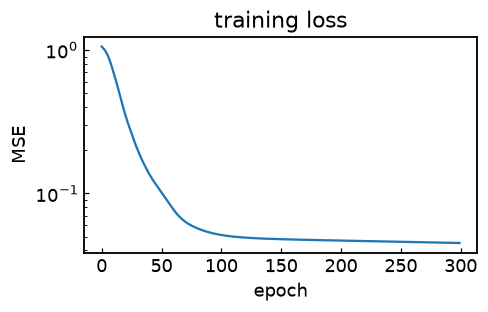

In [4]:
d = Cs.shape[1]
class AE(nn.Module):
    def __init__(self, d, latent=2):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d, 16), nn.ReLU(), nn.Linear(16, latent))  # 56->16->2
        self.decoder = nn.Sequential(nn.Linear(latent, 16), nn.ReLU(), nn.Linear(16, d))  # 2->16->56
    def forward(self, x):
        z = self.encoder(x)                      # z = the 2-D latent code
        return self.decoder(z), z                # rebuilt curve, and the code

ae = AE(d); opt = torch.optim.Adam(ae.parameters(), 5e-3); lossf = nn.MSELoss()
losses = []
for epoch in range(300):                         # 300 quick full-batch steps
    opt.zero_grad()
    xr, _ = ae(Xt)                               # rebuild all curves
    loss = lossf(xr, Xt)                          # how far off are we?
    loss.backward(); opt.step()                  # improve
    losses.append(loss.item())
print("final reconstruction MSE:", round(losses[-1], 4))

fig, ax = plt.subplots(figsize=(4.6, 3)); ax.plot(losses)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_yscale("log")
ax.set_title("training loss"); fig.tight_layout()

## 3 · The latent space

Each curve is now a single point in 2-D. Colour by hardness: the latent axes have organised the
curves by their mechanical response — **with no labels given**.

> ✅ **When you run the next cell, you should see:** left: the latent scatter, smoothly coloured by hardness (structure!); right: k-means run *in* that latent space, recovering two groups.

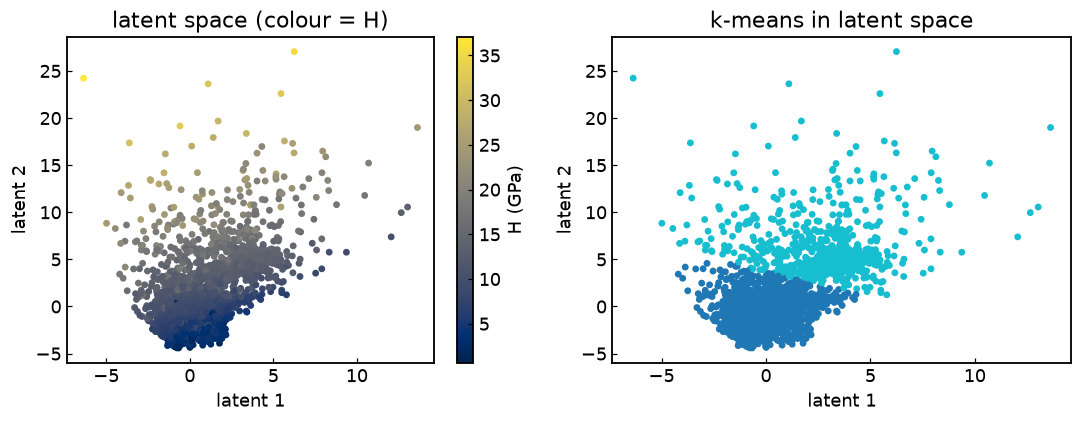

In [5]:
ae.eval()
with torch.no_grad():
    recon, Z = ae(Xt)
Z = Z.numpy()
kl = KMeans(2, n_init=10, random_state=0).fit_predict(Z)     # cluster the latent space (a separate step)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
s0 = ax[0].scatter(Z[:, 0], Z[:, 1], c=afm["H"], s=12, cmap="cividis")
ax[0].set_xlabel("latent 1"); ax[0].set_ylabel("latent 2"); ax[0].set_title("latent space (colour = H)")
plt.colorbar(s0, ax=ax[0], label="H (GPa)")
ax[1].scatter(Z[:, 0], Z[:, 1], c=kl, s=12, cmap="tab10")
ax[1].set_xlabel("latent 1"); ax[1].set_ylabel("latent 2"); ax[1].set_title("k-means in latent space")
fig.tight_layout()

*🖼 **Figure.** The hardness gradient across the latent space (left) means the network learned a meaningful ordering of curves on its own. We cluster that space as a plain, separate step (right) — encode first, cluster after.*

## 4 · Reconstruction error = anomaly score

Curves the autoencoder rebuilds **poorly** are unusual — pop-ins, cracked indents, surface
artefacts. That gives a **label-free** way to triage a big map: flag the worst-reconstructed curves.

> 🧠 **anomaly** — a sample unlike the rest. Since the autoencoder only learned *typical* curves, it reconstructs odd ones badly — so a high error = 'look at this one'.

> ✅ **When you run the next cell, you should see:** left: a histogram of reconstruction error with the top 3% flagged; right: the three worst-reconstructed curves (they look atypical). ~25 flagged.

flagged anomalies: 197


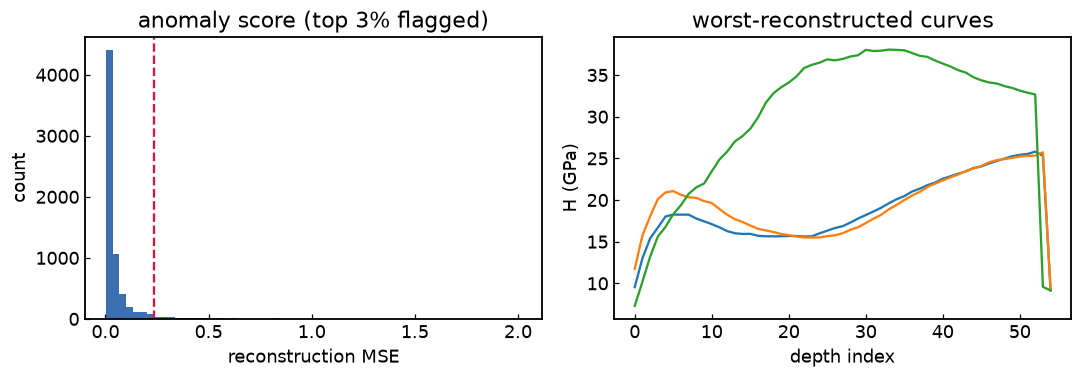

In [6]:
err = ((recon - Xt) ** 2).mean(1).numpy()        # per-curve reconstruction error
thr = np.quantile(err, 0.97)                      # flag the worst 3%

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(err, bins=60, color="#3b6fb0"); ax[0].axvline(thr, c="crimson", ls="--")
ax[0].set_xlabel("reconstruction MSE"); ax[0].set_ylabel("count")
ax[0].set_title("anomaly score (top 3% flagged)")
worst = np.argsort(err)[-3:]                       # the three most anomalous curves
for i in worst:
    ax[1].plot(scaler.inverse_transform(Cs[i][None])[0], lw=1.5)
ax[1].set_title("worst-reconstructed curves"); ax[1].set_xlabel("depth index"); ax[1].set_ylabel("H (GPa)")
fig.tight_layout()
print("flagged anomalies:", int((err > thr).sum()))

*🖼 **Figure.** The flagged curves (right) are visibly unusual. In a real workflow you would inspect these before trusting any downstream statistics — a free quality-control pass.*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert losses[-1] < 0.2, "the autoencoder should reconstruct curves well (low MSE)"
assert int((err > thr).sum()) > 0, "some anomalies should be flagged"
print("self-check passed ✓ — autoencoder trained")

self-check passed ✓ — autoencoder trained


## ✅ Recap
- An **autoencoder** learns a compact **latent space** (learned coordinates) where similar curves cluster together.
- We **encode first, then cluster** the latent space as a separate, transparent step.
- **Reconstruction error** is a free **anomaly detector** for flagging bad or unusual indents.

> ℹ️ This is a **plain** autoencoder on purpose — reconstruct first, cluster after. More advanced
> representation-learning methods exist and go further, but this simple version already gives you
> the intuition and a genuinely useful tool.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Widen the latent space from 2 to 3 (`AE(d, latent=3)`). Does the final reconstruction MSE drop?
2. Train for only 50 epochs instead of 300. Is the latent space still organised by hardness?
3. Lower the anomaly threshold to the top 1% (`np.quantile(err, 0.99)`). How many curves are flagged now?

## 🩹 Common errors & fixes
- **Loss is flat / NaN** → lower the learning rate (`5e-3` → `1e-3`) and re-run from the model cell.
- **Latent plot looks like a blob** → train longer, or check the curves were standardised (Section 1).
- **Shape error after editing the network** → use **Kernel → Restart & Run All**; layer sizes must match.

---
**Next:** the refreshed classics — **`10_cnn_mnist`**, **`11_popin_detection`**, **`12_regression_curvefitting`** — and the new evaluation notebook **`03a`**.